# Deep Learning Final Project: Florence-2 Architecture & Robustness Analysis

**Authors:** Yonathan (ID: 314833302) & Yarin (ID: 214197766)

**Research Paper:** [Florence-2: Advancing a Unified Representation for a Variety of Vision Tasks (2023)](https://arxiv.org/pdf/2311.06242)  
**Dataset Utilized:** [COCO Validation Split (HuggingFace API)](https://huggingface.co/datasets/detection-datasets/coco)

## Abstract & Methodology
This notebook implements and evaluates the Microsoft Florence-2-base vision-language model for zero-shot object detection.
The evaluation focuses on three aspects:
1. **Quantitative Baseline** — evaluation on the COCO validation dataset using Recall@0.5 and Mean IoU.
2. **Robustness Analysis** — stress-testing under progressive image brightness degradation.
3. **Qualitative Failure Analysis** — investigation of difficult dense-scene cases and detection failures.

In [ ]:
#Cell 1:When running at colab
#!pip install -q transformers==4.41.2 tokenizers==0.19.1 einops timm datasets pandas tqdm matplotlib seaborn

In [ ]:
# Cell 2: Imports, environment setup, and loading the model
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from unittest.mock import patch
from transformers.dynamic_module_utils import get_imports
from transformers import AutoProcessor, AutoModelForCausalLM
from datasets import load_dataset

# Florence-2 checks for flash_attn, but this environment does not need that optional package.
def fixed_get_imports(filename: str | os.PathLike) -> list[str]:
    if not str(filename).endswith("modeling_florence2.py"):
        return get_imports(filename)
    imports = get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[*] Hardware Accelerator: {device}")
print("[*] Loading Microsoft Florence-2-base weights...")
model_id = "microsoft/Florence-2-base"
with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
    model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True).to(device)
    processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model.eval()
print("[*] Model successfully loaded and set to evaluation mode!")

In [6]:
# Cell 3: Metric calculations and the evaluation helper

def compute_iou(box1, box2):
    """
    Computes Intersection over Union (IoU) between two bounding boxes.
    This purely geometric metric answers: "How well does our predicted box align with the ground truth?"
    Format expected: [xmin, ymin, xmax, ymax]
    """
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # No overlap means there is no intersection area to count.
    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = float(box1_area + box2_area - intersection_area)
    return intersection_area / union_area if union_area > 0 else 0.0


def evaluate_image_predictions(gt_boxes, gt_labels, pred_boxes, pred_labels, iou_threshold=0.5):
    """
    Evaluates Florence-2's predictions against Ground Truth (GT).
    Requires a dual-match:
    1. Semantic Match: The predicted class text must match the GT class text.
    2. Spatial Match: The geometric IoU must be >= threshold (default 0.5).
    """
    matched_gt = set()
    true_positives = 0
    iou_scores = []

    for p_box, p_label in zip(pred_boxes, pred_labels):
        best_iou = 0.0
        best_gt_idx = -1

        for idx, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
            # First make sure the label refers to the same kind of object, ignoring capitalization and extra spaces.
            if idx not in matched_gt and p_label.lower().strip() in gt_label.lower().strip():
                iou = compute_iou(p_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = idx

        # Count the prediction only when it clears the IoU threshold and has a matching ground-truth box.
        if best_iou >= iou_threshold and best_gt_idx != -1:
            true_positives += 1
            matched_gt.add(best_gt_idx)
            iou_scores.append(best_iou)

    mean_iou = np.mean(iou_scores) if len(iou_scores) > 0 else 0.0
    return true_positives, mean_iou

In [ ]:
# Cell 4: Quantitative baseline experiment on the COCO validation split

print("[*] Loading COCO validation dataset (1,000 images)...")
dataset = load_dataset("detection-datasets/coco", split="val[:1000]")

# The dataset schema is not always represented the same way, so handle the common variants here.
objects_feature = dataset.features['objects']
if hasattr(objects_feature, 'feature'):
    category_names = objects_feature.feature['category'].names
elif isinstance(objects_feature, dict) and 'category' in objects_feature:
    cat_feature = objects_feature['category']
    category_names = cat_feature.feature.names if hasattr(cat_feature, 'feature') else cat_feature.names
else:
    category_names = dataset.features['objects']['category'].names
# -------------------------------------------------------------------------------------

task_prompt = "<OD>" # Object Detection textual token
experiment_metrics = []

print("[*] Starting quantitative evaluation loop...\n")

for i, item in enumerate(tqdm(dataset, desc="Evaluating Florence-2")):
    try:
        image = item["image"].convert("RGB")

        # Pull out the ground-truth boxes and turn category IDs into readable class names.
        gt_data = item["objects"]
        gt_boxes = gt_data["bbox"]
        gt_labels = [category_names[cat_id] for cat_id in gt_data["category"]]

        if len(gt_boxes) == 0:
            continue # Empty scenes cannot contribute to recall, so skip them.

        # Run Florence-2 on the image and let it generate the detection sequence.
        inputs = processor(text=task_prompt, images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            generated_ids = model.generate(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                max_new_tokens=1024,
                num_beams=3 # Beam search gives the decoder a few candidate sequences to compare.
            )

        # Convert Florence-2's textual response back into image-space bounding boxes.
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
        parsed_answer = processor.post_process_generation(
            generated_text, task=task_prompt, image_size=(image.width, image.height)
        )

        # Pull the predicted boxes and labels out of the post-processed response.
        od_result = parsed_answer.get('<OD>', {})
        pred_boxes = od_result.get('bboxes', [])
        pred_labels = od_result.get('labels', [])

        # Compare predictions with the ground truth using recall and mean IoU.
        true_positives, mean_iou = evaluate_image_predictions(
            gt_boxes, gt_labels, pred_boxes, pred_labels, iou_threshold=0.5
        )

        recall = true_positives / len(gt_boxes)

        experiment_metrics.append({
            "image_index": i,
            "gt_objects_count": len(gt_boxes),
            "pred_objects_count": len(pred_boxes),
            "true_positives": true_positives,
            "recall@0.5": recall,
            "mean_iou": mean_iou
        })

    except Exception as e:
        continue

# Put the results in a table so the later plots can read them consistently.
df_metrics = pd.DataFrame(experiment_metrics)
df_metrics.to_csv("florence2_coco_quantitative_baseline.csv", index=False)
print("\n[*] Evaluation successfully saved to 'florence2_coco_quantitative_baseline.csv'!")

  FLORENCE-2 ZERO-SHOT COCO BENCHMARK     
  Mean Recall@0.5  : 60.68%
  Mean IoU (Hits)  : 0.8762


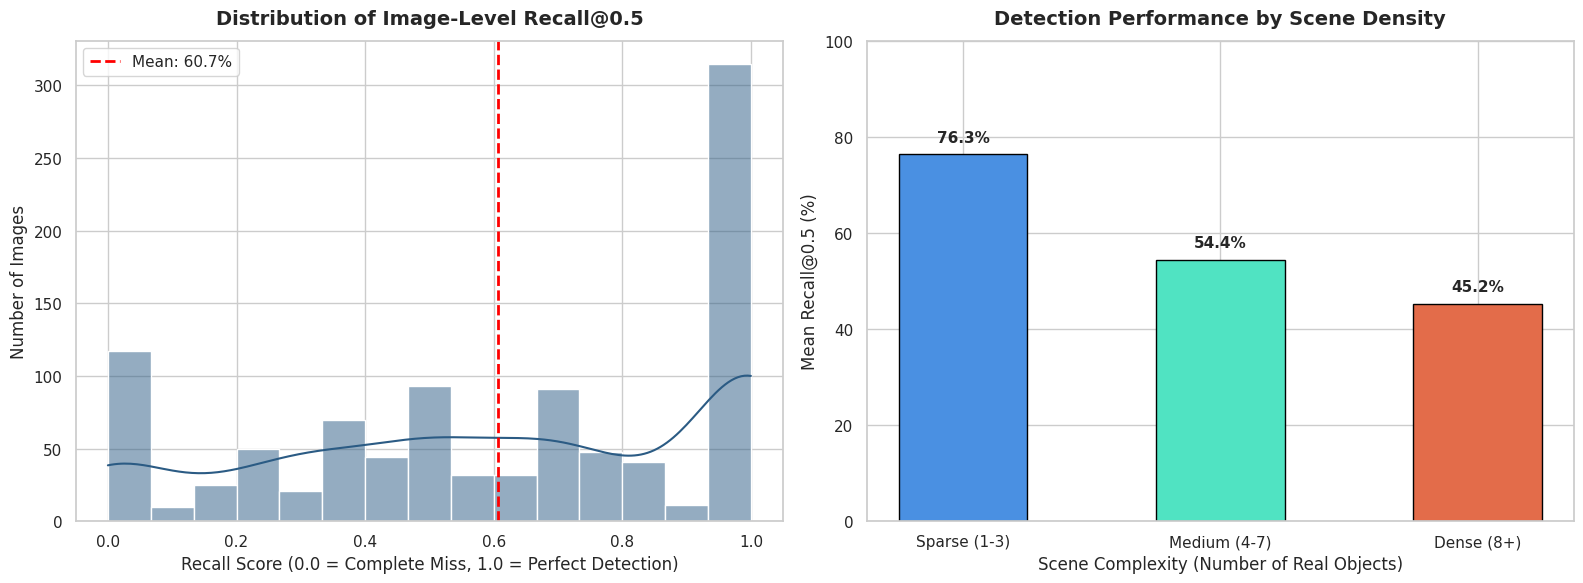

In [8]:
# Cell 5: Visualizing the baseline results for the presentation

df = pd.read_csv("florence2_coco_quantitative_baseline.csv")

# Start with the two headline numbers we want to report.
global_recall = df["recall@0.5"].mean() * 100
global_iou = df[df["mean_iou"] > 0]["mean_iou"].mean()

print(f"==========================================")
print(f"  FLORENCE-2 ZERO-SHOT COCO BENCHMARK     ")
print(f"==========================================")
print(f"  Mean Recall@0.5  : {global_recall:.2f}%")
print(f"  Mean IoU (Hits)  : {global_iou:.4f}")
print(f"==========================================")

# Use a restrained theme so the plots stay readable on presentation slides.
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Distribution of Recall Scores across Images
sns.histplot(df["recall@0.5"], bins=15, kde=True, color="#2B5B84", ax=axes[0])
axes[0].set_title("Distribution of Image-Level Recall@0.5", fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel("Recall Score (0.0 = Complete Miss, 1.0 = Perfect Detection)", fontsize=12)
axes[0].set_ylabel("Number of Images", fontsize=12)
axes[0].axvline(df["recall@0.5"].mean(), color="red", linestyle="--", linewidth=2, label=f'Mean: {global_recall:.1f}%')
axes[0].legend(loc="upper left", fontsize=11)

# The second plot checks whether recall drops as the number of objects in a scene grows.
df['scene_density'] = pd.cut(df['gt_objects_count'], bins=[0, 3, 7, 100], labels=['Sparse (1-3)', 'Medium (4-7)', 'Dense (8+)'])
density_recall = df.groupby('scene_density', observed=True)['recall@0.5'].mean() * 100

bars = axes[1].bar(density_recall.index, density_recall.values, color=["#4A90E2", "#50E3C2", "#E36C4A"], width=0.5, edgecolor="black")
axes[1].set_title("Detection Performance by Scene Density", fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel("Scene Complexity (Number of Real Objects)", fontsize=12)
axes[1].set_ylabel("Mean Recall@0.5 (%)", fontsize=12)
axes[1].set_ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Robustness stress test with progressively darker images
import torchvision.transforms.functional as TF

print("[*] Preparing Stress-Test Experiment (Distribution Shift via Brightness)...")

# Use 100 varied images so each brightness setting can be tested in a reasonable amount of time.
stress_test_subset = dataset.select(range(100))

# 1.0 is the original image; 0.1 gives us an almost dark frame to test the limit.
brightness_levels = [1.0, 0.8, 0.6, 0.4, 0.2, 0.1]
degradation_results = []

for b_level in brightness_levels:
    print(f"\n[*] Testing Brightness Level: {b_level * 100:.0f}%...")
    true_positives_total = 0
    gt_total = 0

    for item in tqdm(stress_test_subset, desc=f"Brightness {b_level}"):
        try:
            original_image = item["image"].convert("RGB")

            # Darken the image by a controlled amount to simulate a lighting shift.
            degraded_image = TF.adjust_brightness(original_image, brightness_factor=b_level)

            # Read the ground-truth boxes and labels for this image.
            gt_data = item["objects"]
            gt_boxes = gt_data["bbox"]
            gt_labels = [category_names[cat_id] for cat_id in gt_data["category"]]

            if len(gt_boxes) == 0:
                continue

            gt_total += len(gt_boxes)

            # Run the same Florence-2 inference pipeline on the degraded image.
            inputs = processor(text=task_prompt, images=degraded_image, return_tensors="pt").to(device)
            with torch.no_grad():
                generated_ids = model.generate(
                    input_ids=inputs["input_ids"],
                    pixel_values=inputs["pixel_values"],
                    max_new_tokens=1024,
                    num_beams=3
                )

            generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
            parsed_answer = processor.post_process_generation(
                generated_text, task=task_prompt, image_size=(degraded_image.width, degraded_image.height)
            )

            # A hit still needs both a matching label and IoU >= 0.5, just like the baseline.
            od_result = parsed_answer.get('<OD>', {})
            pred_boxes = od_result.get('bboxes', [])
            pred_labels = od_result.get('labels', [])

            hits, _ = evaluate_image_predictions(gt_boxes, gt_labels, pred_boxes, pred_labels, iou_threshold=0.5)
            true_positives_total += hits

        except Exception:
            continue

    # Convert the total hits into recall for this particular brightness level.
    level_recall = (true_positives_total / gt_total) * 100 if gt_total > 0 else 0
    degradation_results.append({
        "brightness_level": f"{int(b_level * 100)}%",
        "brightness_value": b_level,
        "recall_score": level_recall
    })

# Save the stress-test table so the degradation curve can be plotted separately.
df_stress = pd.DataFrame(degradation_results)
df_stress.to_csv("florence2_stress_test_results.csv", index=False)
print("\n[*] Stress-Test completed and saved to 'florence2_stress_test_results.csv'!")

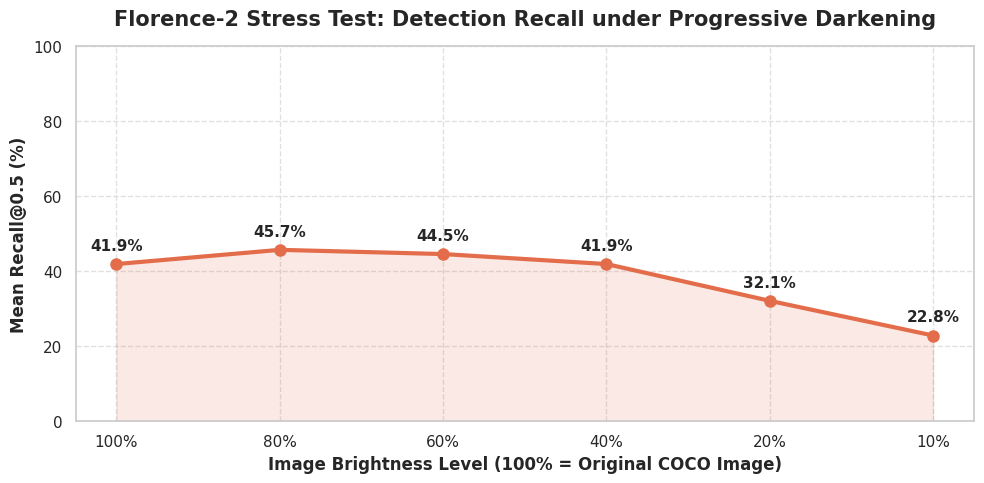

In [10]:
# Cell 7: Plot the brightness degradation curve for the presentation

df_stress = pd.read_csv("florence2_stress_test_results.csv")

plt.figure(figsize=(10, 5))

# Connect each measured brightness level so the trend is easy to see.
plt.plot(
    df_stress["brightness_level"],
    df_stress["recall_score"],
    marker='o',
    linewidth=3,
    markersize=8,
    color="#E36C4A",
    label="Florence-2 Recall@0.5"
)

# Shade the area under the curve to make the drop in recall more visible.
plt.fill_between(
    df_stress["brightness_level"],
    df_stress["recall_score"],
    color="#E36C4A",
    alpha=0.15
)

plt.title("Florence-2 Stress Test: Detection Recall under Progressive Darkening", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Image Brightness Level (100% = Original COCO Image)", fontsize=12, fontweight='bold')
plt.ylabel("Mean Recall@0.5 (%)", fontsize=12, fontweight='bold')
plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.6)

# Label each point so the slide does not require estimating values from the axis.
for idx, row in df_stress.iterrows():
    plt.text(
        idx,
        row["recall_score"] + 3,
        f"{row['recall_score']:.1f}%",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.tight_layout()
plt.show()

[*] Hunting for Edge Cases: Scenes with high density but 0% Recall...


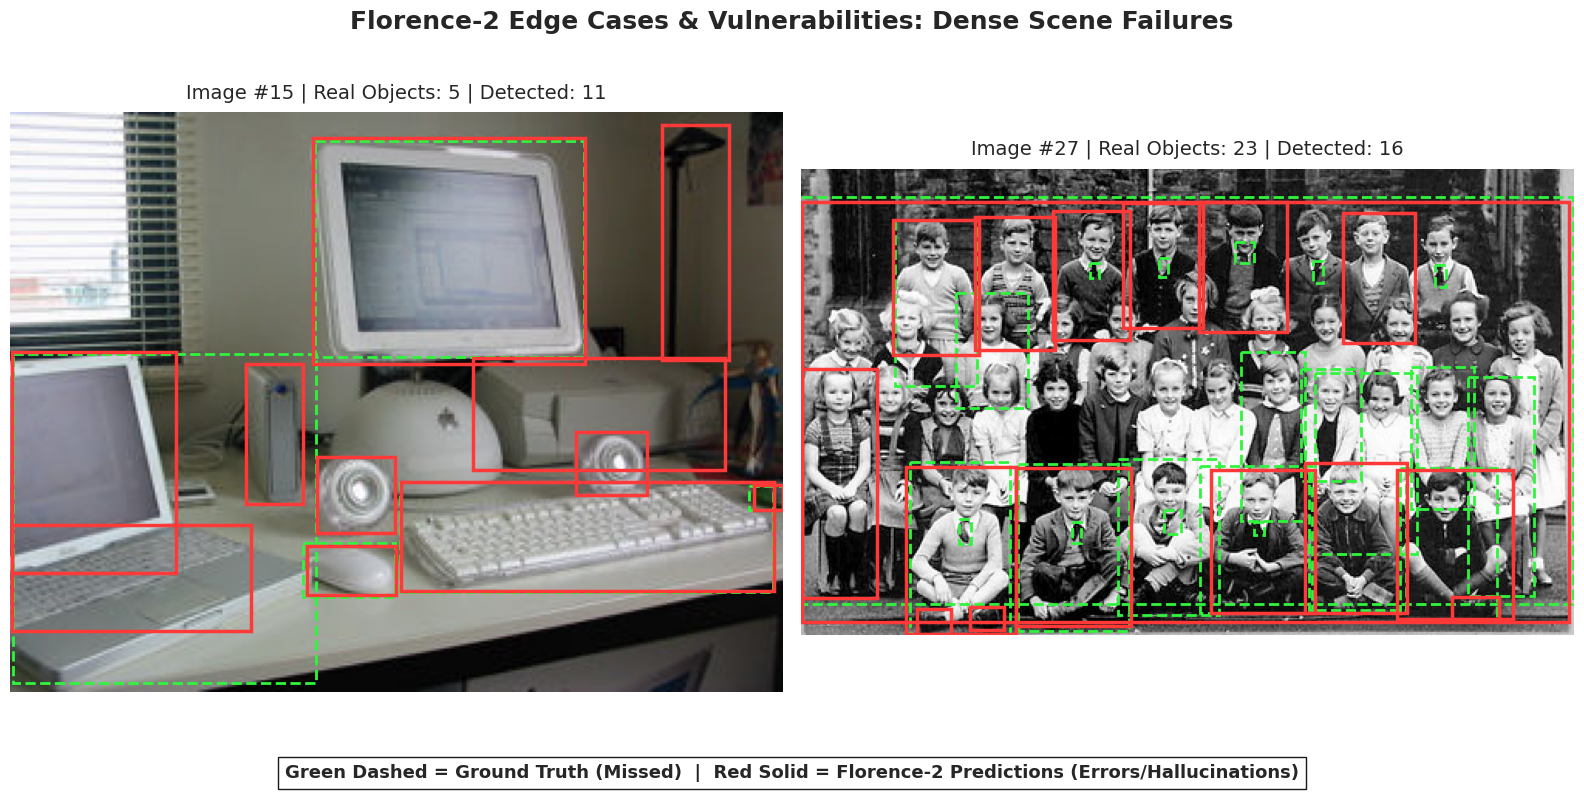

In [11]:
# Cell 8: Extract and visualize difficult cases for qualitative analysis
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

print("[*] Hunting for Edge Cases: Scenes with high density but 0% Recall...")

# Load the baseline metrics produced in Cell 4.
df_metrics = pd.read_csv("florence2_coco_quantitative_baseline.csv")

# Focus on complete misses in scenes with at least four objects, where the model has more to keep track of.
hard_cases = df_metrics[(df_metrics["recall@0.5"] == 0.0) & (df_metrics["gt_objects_count"] >= 4)]

# Take the first two examples that meet this failure criterion.
edge_case_indices = hard_cases["image_index"].head(2).tolist()

# Set up a two-panel figure so the selected failures can be compared side by side.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Florence-2 Edge Cases & Vulnerabilities: Dense Scene Failures", fontsize=18, fontweight='bold')

# Revisit each selected image and overlay its reference and predicted boxes.
for plot_idx, img_idx in enumerate(edge_case_indices):
    item = dataset[img_idx]
    image = item["image"].convert("RGB")

    # Get the reference boxes that define what should have been detected.
    gt_boxes = item["objects"]["bbox"]

    # Run the model again for these two examples so we can draw its actual mistakes.
    inputs = processor(text="<OD>", images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=1024,
            num_beams=3
        )

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(generated_text, task="<OD>", image_size=(image.width, image.height))

    pred_boxes = parsed_answer.get('<OD>', {}).get('bboxes', [])

    # Draw the image and leave room for the box overlays.
    ax = axes[plot_idx]
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"Image #{img_idx} | Real Objects: {len(gt_boxes)} | Detected: {len(pred_boxes)}", fontsize=14, pad=10)

    # Green dashed boxes mark the ground truth, or objects the model missed.
    for box in gt_boxes:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 linewidth=2, edgecolor='#2FF53D', facecolor='none', linestyle='dashed')
        ax.add_patch(rect)

    # Red solid boxes show what Florence-2 actually predicted, including false detections.
    for box in pred_boxes:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 linewidth=2.5, edgecolor='#FF3838', facecolor='none')
        ax.add_patch(rect)

# Add one shared legend below both panels to keep the plots uncluttered.
fig.text(0.5, 0.02, "Green Dashed = Ground Truth (Missed)  |  Red Solid = Florence-2 Predictions (Errors/Hallucinations)",
         ha='center', fontsize=13, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=5))

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.08)
plt.show()